# Бизнес-метрики и продуктовая аналитика

В этом ноутбуке я беру очищенные данные из EDA, восстанавливаю сущности заказа, клиента и товара, считаю основные бизнес-метрики и готовлю агрегаты для дашборда.

Главная логика: строка - это товарная позиция, а заказ собирается через Invoice.

In [258]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Загрузка очищенных данных

In [259]:
data = pd.read_csv('../data/clean_online_retail_II.csv', parse_dates=['InvoiceDate'])

data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,InvoiceDateOnly,InvoiceMonth,InvoiceYear,is_return,is_sale,CheckoutPrice,SalesAmount,RefundAmount,NetAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12-01,2009-12,2009,False,True,83.4,83.4,0.0,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009-12,2009,False,True,81.0,81.0,0.0,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009-12,2009,False,True,81.0,81.0,0.0,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12-01,2009-12,2009,False,True,100.8,100.8,0.0,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12-01,2009-12,2009,False,True,30.0,30.0,0.0,30.0


## 2. Сущность заказа

В исходных данных заказа как отдельной таблицы нет, но его можно восстановить через Invoice. Один Invoice содержит несколько строк с разными товарами, то есть несколько товарных позиций одного заказа.

In [260]:
orders = data.groupby('Invoice').agg(
    CustomerID=('Customer ID', 'max'),
    Country=('Country', 'max'),
    InvoiceDate=('InvoiceDate', 'min'),
    IsReturn=('is_return', 'max'),
    IsSale=('is_sale', 'max'),
    GrossRevenue=('SalesAmount', 'sum'),
    RefundAmount=('RefundAmount', 'sum'),
    NetRevenue=('NetAmount', 'sum'),
    UniqueProducts=('StockCode', 'nunique')
).reset_index()

items_sold = data[data['is_sale']].groupby('Invoice')['Quantity'].sum()
items_returned = data[data['is_return']].groupby('Invoice')['Quantity'].sum().abs()

orders = orders.merge(items_sold.rename('ItemsSold'), on='Invoice', how='left')
orders = orders.merge(items_returned.rename('ItemsReturned'), on='Invoice', how='left')

orders['InvoiceDateOnly'] = orders['InvoiceDate'].dt.date
orders['InvoiceMonth'] = orders['InvoiceDate'].dt.to_period('M')

orders.head()

,Invoice,CustomerID,Country,InvoiceDate,IsReturn,IsSale,GrossRevenue,RefundAmount,NetRevenue,UniqueProducts,ItemsSold,ItemsReturned,InvoiceDateOnly,InvoiceMonth
0,489434,13085.0,United Kingdom,2009-12-01 07:45:00,False,True,505.30,0.0,505.30,8,166.0,NaN,2009-12-01,2009-12
1,489435,13085.0,United Kingdom,2009-12-01 07:46:00,False,True,145.80,0.0,145.80,4,60.0,NaN,2009-12-01,2009-12
2,489436,13078.0,United Kingdom,2009-12-01 09:06:00,False,True,630.33,0.0,630.33,19,193.0,NaN,2009-12-01,2009-12
3,489437,15362.0,United Kingdom,2009-12-01 09:08:00,False,True,310.75,0.0,310.75,23,145.0,NaN,2009-12-01,2009-12
4,489438,18102.0,United Kingdom,2009-12-01 09:24:00,False,True,2286.24,0.0,2286.24,17,826.0,NaN,2009-12-01,2009-12


In [261]:
orders.to_csv('../data/aggregates/orders.csv', index=False)

## 3. Общие бизнес-метрики

Основные формулы:

- GrossRevenue = сумма продаж без возвратов
- RefundAmount = сумма возвратов в положительном виде
- NetRevenue = GrossRevenue - RefundAmount
- AOV = GrossRevenue / количество заказов
- RefundRate = RefundAmount / GrossRevenue
- RepeatPurchaseRate = клиенты с 2+ заказами / активные клиенты

In [262]:
sales_orders = orders[orders['IsReturn'] == False]
return_orders = orders[orders['IsReturn'] == True]

customer_orders = sales_orders.dropna(subset=['CustomerID']).groupby('CustomerID')['Invoice'].nunique()

metrics = pd.DataFrame({
    'metric': [
        'gross_revenue',
        'refund_amount',
        'net_revenue',
        'sales_orders',
        'return_orders',
        'active_customers',
        'aov',
        'avg_items_per_order',
        'avg_unique_products_per_order',
        'refund_rate',
        'repeat_purchase_rate'
    ],
    'value': [
        sales_orders['GrossRevenue'].sum(),
        return_orders['RefundAmount'].sum(),
        orders['NetRevenue'].sum(),
        sales_orders['Invoice'].nunique(),
        return_orders['Invoice'].nunique(),
        sales_orders['CustomerID'].nunique(),
        sales_orders['GrossRevenue'].sum() / sales_orders['Invoice'].nunique(),
        sales_orders['ItemsSold'].sum() / sales_orders['Invoice'].nunique(),
        sales_orders['UniqueProducts'].mean(),
        return_orders['RefundAmount'].sum() / sales_orders['GrossRevenue'].sum(),
        (customer_orders >= 2).sum() / customer_orders.count()
    ]
})

metrics

,metric,value
0,gross_revenue,2.010900e+07
1,refund_amount,7.265194e+05
2,net_revenue,1.938248e+07
3,sales_orders,3.951600e+04
4,return_orders,7.405000e+03
5,active_customers,5.852000e+03
6,aov,5.088824e+02
7,avg_items_per_order,2.885510e+02
8,avg_unique_products_per_order,2.510155e+01
9,refund_rate,3.612907e-02


In [263]:
metrics.to_csv('../data/aggregates/main_metrics.csv', index=False)

## 4. Динамика по месяцам

In [264]:
monthly = orders.groupby('InvoiceMonth').agg(
    GrossRevenue=('GrossRevenue', 'sum'),
    RefundAmount=('RefundAmount', 'sum'),
    NetRevenue=('NetRevenue', 'sum'),
    SalesOrders=('Invoice', lambda x: x[orders.loc[x.index, 'IsReturn'] == False].nunique()),
    ReturnOrders=('Invoice', lambda x: x[orders.loc[x.index, 'IsReturn'] == True].nunique()),
    ActiveCustomers=('CustomerID', 'nunique'),
    ItemsSold=('ItemsSold', 'sum'),
    ItemsReturned=('ItemsReturned', 'sum')
).reset_index()

first_order = sales_orders.dropna(subset=['CustomerID']).groupby('CustomerID')['InvoiceDate'].min()
first_order_month = first_order.dt.to_period('M')
new_customers = first_order_month.value_counts().sort_index()

monthly['NewCustomers'] = monthly['InvoiceMonth'].map(new_customers).fillna(0).astype(int)
monthly['ReturningCustomers'] = monthly['ActiveCustomers'] - monthly['NewCustomers']

monthly['AvgItemsPerOrder'] = monthly['ItemsSold'] / monthly['SalesOrders']
monthly['RefundRate'] = monthly['RefundAmount'] / monthly['GrossRevenue']
monthly['RevenuePerCustomer'] = monthly['GrossRevenue'] / monthly['ActiveCustomers']
monthly['PurchaseFrequency'] = monthly['SalesOrders'] / monthly['ActiveCustomers']

monthly

,InvoiceMonth,GrossRevenue,RefundAmount,NetRevenue,SalesOrders,ReturnOrders,ActiveCustomers,ItemsSold,ItemsReturned,NewCustomers,ReturningCustomers,AvgItemsPerOrder,RefundRate,RevenuePerCustomer,PurchaseFrequency
0,2009-12,800939.83,19561.28,781378.55,1666,379,1040,426709.0,9984.0,951,89,256.127851,0.024423,770.134452,1.601923
1,2010-01,613824.59,7465.63,606358.96,1049,241,744,391261.0,3304.0,368,376,372.984747,0.012162,825.033051,1.409946
2,2010-02,539728.55,12584.39,527144.16,1189,219,803,382521.0,6740.0,375,428,321.716569,0.023316,672.140162,1.480697
3,2010-03,764293.49,9657.20,754636.29,1647,351,1094,526349.0,4274.0,441,653,319.580449,0.012635,698.622934,1.505484
4,2010-04,648886.07,10025.26,638860.81,1435,263,987,367549.0,5998.0,294,693,256.131707,0.015450,657.432695,1.453901
5,2010-05,645627.64,37294.14,608333.50,1484,387,1059,396773.0,16568.0,255,804,267.367251,0.057764,609.657828,1.401322
6,2010-06,699172.30,26344.01,672828.29,1612,318,1080,408013.0,15366.0,267,813,253.109801,0.037679,647.381759,1.492593
7,2010-07,634886.18,17132.73,617753.45,1507,314,984,338573.0,5987.0,185,799,224.666888,0.026986,645.209533,1.531504
8,2010-08,676059.87,12418.65,663641.22,1402,242,963,472970.0,6276.0,163,800,337.353780,0.018369,702.035171,1.455867
9,2010-09,871859.66,27777.97,844081.69,1789,319,1186,584850.0,94286.0,239,947,326.914477,0.031861,735.126189,1.508432


In [265]:
monthly.to_csv('../data/aggregates/monthly_kpi.csv', index=False)

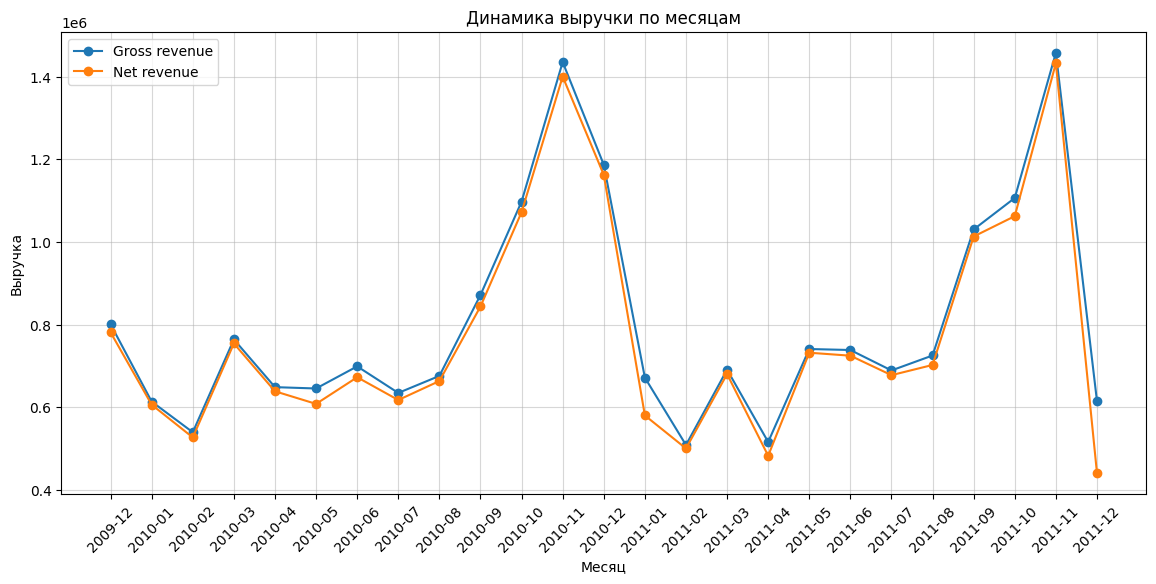

In [266]:
plt.figure(figsize=(14, 6))
plt.plot(monthly['InvoiceMonth'].astype(str), monthly['GrossRevenue'], marker='o', label='Gross revenue')
plt.plot(monthly['InvoiceMonth'].astype(str), monthly['NetRevenue'], marker='o', label='Net revenue')
plt.xticks(rotation=45)
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.title('Динамика выручки по месяцам')
plt.grid(alpha=0.5)
plt.legend()

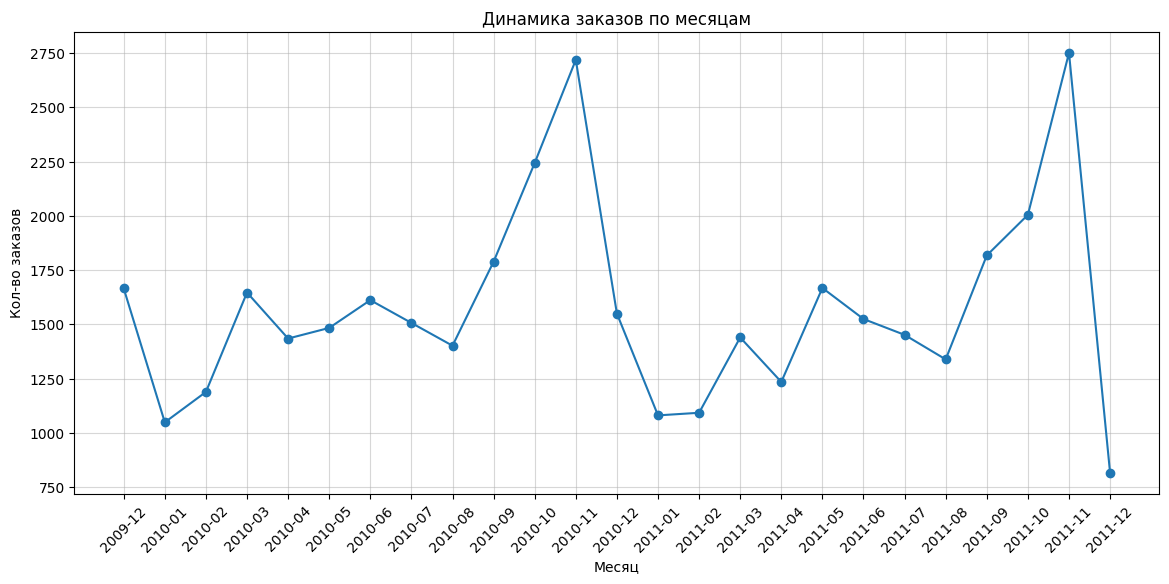

In [267]:
plt.figure(figsize=(14, 6))
plt.plot(monthly['InvoiceMonth'].astype(str), monthly['SalesOrders'], marker='o')
plt.xticks(rotation=45)
plt.xlabel('Месяц')
plt.ylabel('Кол-во заказов')
plt.title('Динамика заказов по месяцам')
plt.grid(alpha=0.5)

## 5. Динамика по дням

In [268]:
daily = orders.groupby('InvoiceDateOnly').agg(
    GrossRevenue=('GrossRevenue', 'sum'),
    RefundAmount=('RefundAmount', 'sum'),
    NetRevenue=('NetRevenue', 'sum'),
    SalesOrders=('Invoice', lambda x: x[orders.loc[x.index, 'IsReturn'] == False].nunique()),
    ReturnOrders=('Invoice', lambda x: x[orders.loc[x.index, 'IsReturn'] == True].nunique()),
    ActiveCustomers=('CustomerID', 'nunique'),
    ItemsSold=('ItemsSold', 'sum'),
    ItemsReturned=('ItemsReturned', 'sum')
).reset_index()

first_order = sales_orders.dropna(subset=['CustomerID']).groupby('CustomerID')['InvoiceDate'].min()
first_order_day = first_order.dt.to_period('D')
new_customers = first_order_day.value_counts().sort_index()

daily['NewCustomers'] = daily['InvoiceDateOnly'].map(new_customers).fillna(0).astype(int)
daily['ReturningCustomers'] = daily['ActiveCustomers'] - daily['NewCustomers']

daily['AvgItemsPerOrder'] = daily['ItemsSold'] / daily['SalesOrders']
daily['RefundRate'] = daily['RefundAmount'] / daily['GrossRevenue']
daily['RevenuePerCustomer'] = daily['GrossRevenue'] / daily['ActiveCustomers']
daily['PurchaseFrequency'] = daily['SalesOrders'] / daily['ActiveCustomers']

daily

,InvoiceDateOnly,GrossRevenue,RefundAmount,NetRevenue,SalesOrders,ReturnOrders,ActiveCustomers,ItemsSold,ItemsReturned,NewCustomers,ReturningCustomers,AvgItemsPerOrder,RefundRate,RevenuePerCustomer,PurchaseFrequency
0,2009-12-01,52591.40,1297.79,51293.61,117,37,114,26174.0,626.0,0,114,223.709402,0.024677,461.328070,1.026316
1,2009-12-02,62053.03,501.35,61551.68,115,12,98,31891.0,264.0,0,98,277.313043,0.008079,633.194184,1.173469
2,2009-12-03,73090.58,3901.43,69189.15,124,13,116,49238.0,2397.0,0,116,397.080645,0.053378,630.091207,1.068966
3,2009-12-04,39499.81,349.55,39150.26,88,12,82,21307.0,104.0,0,82,242.125000,0.008849,481.705000,1.073171
4,2009-12-05,9803.05,0.00,9803.05,30,0,26,5119.0,0.0,0,26,170.633333,0.000000,377.040385,1.153846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599,2011-12-05,80132.35,467.24,79665.11,126,13,114,43755.0,122.0,0,114,347.261905,0.005831,702.915351,1.105263
600,2011-12-06,55411.69,2480.34,52931.35,114,30,127,30437.0,1106.0,0,127,266.991228,0.044762,436.312520,0.897638
601,2011-12-07,72922.70,227.99,72694.71,105,12,99,41857.0,106.0,0,99,398.638095,0.003126,736.592929,1.060606
602,2011-12-08,77686.31,1077.22,76609.09,120,20,120,35065.0,639.0,0,120,292.208333,0.013866,647.385917,1.000000


In [269]:
daily.to_csv('../data/aggregates/daily_kpi.csv', index=False)

## 6. Анализ стран

In [270]:
country_metrics = sales_orders.groupby('Country').agg(
    GrossRevenue=('GrossRevenue', 'sum'),
    SalesOrders=('Invoice', 'nunique'),
    ActiveCustomers=('CustomerID', 'nunique'),
    ItemsSold=('ItemsSold', 'sum')
).reset_index()

country_refunds = return_orders.groupby('Country')['RefundAmount'].sum()
country_metrics = country_metrics.merge(country_refunds.rename('RefundAmount'), on='Country', how='left')
country_metrics['RefundAmount'] = country_metrics['RefundAmount'].fillna(0)

country_metrics['NetRevenue'] = country_metrics['GrossRevenue'] - country_metrics['RefundAmount']
country_metrics['RevenueShare'] = country_metrics['GrossRevenue'] / country_metrics['GrossRevenue'].sum()
country_metrics['RefundRate'] = country_metrics['RefundAmount'] / country_metrics['GrossRevenue']

country_metrics = country_metrics.sort_values('GrossRevenue', ascending=False)
country_metrics.head(10)

,Country,GrossRevenue,SalesOrders,ActiveCustomers,ItemsSold,RefundAmount,NetRevenue,RevenueShare,RefundRate
40,United Kingdom,17232715.69,36184,5334,9370949.0,641811.11,16590904.58,0.856966,0.037244
11,EIRE,628928.63,581,3,340045.0,20396.25,608532.38,0.031276,0.032430
26,Netherlands,549952.66,216,22,383722.0,3677.98,546274.68,0.027349,0.006688
15,Germany,388829.75,753,107,225878.0,8928.84,379900.91,0.019336,0.022963
14,France,316948.80,598,93,273933.0,17689.19,299259.61,0.015762,0.055811
0,Australia,168484.66,89,15,104084.0,1517.86,166966.80,0.008379,0.009009
34,Spain,98612.79,144,38,50485.0,12955.19,85657.60,0.004904,0.131374
36,Switzerland,94270.29,85,22,52732.0,1106.53,93163.76,0.004688,0.011738
35,Sweden,86353.04,99,19,88554.0,1973.97,84379.07,0.004294,0.022859
10,Denmark,68560.19,42,12,237852.0,4067.10,64493.09,0.003409,0.059322


In [271]:
country_metrics.to_csv('../data/aggregates/country_metrics.csv', index=False)

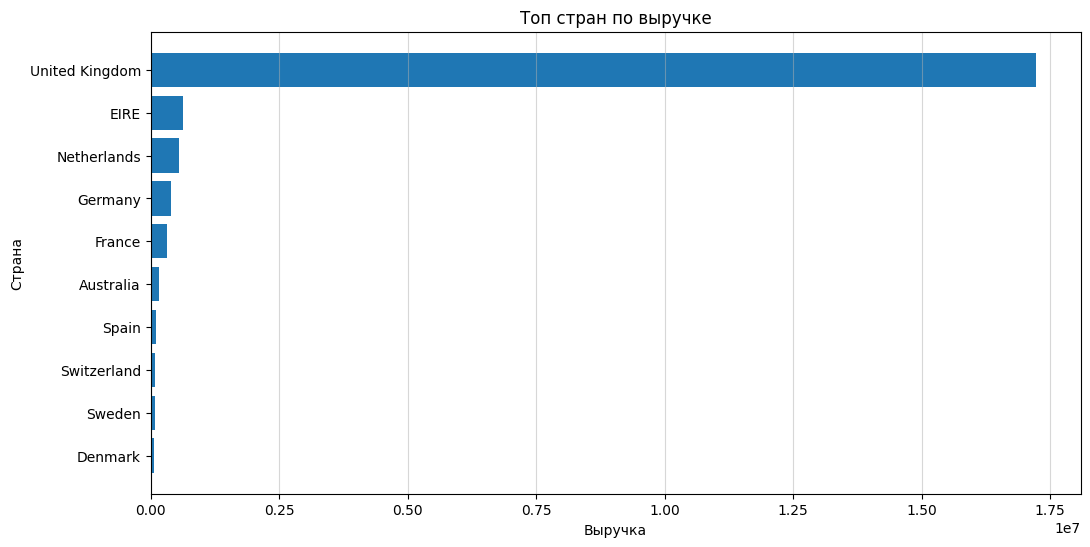

In [272]:
top_countries = country_metrics.head(10).sort_values('GrossRevenue')

plt.figure(figsize=(12, 6))
plt.barh(top_countries['Country'], top_countries['GrossRevenue'])
plt.xlabel('Выручка')
plt.ylabel('Страна')
plt.title('Топ стран по выручке')
plt.grid(axis='x', alpha=0.5)

## 7. Анализ товаров

In [273]:
product_description = data.groupby('StockCode')['Description'].agg(lambda x: x.mode())

product_sales = data[data['is_sale']].groupby('StockCode').agg(
    GrossRevenue=('SalesAmount', 'sum'),
    UnitsSold=('Quantity', 'sum'),
    SalesOrders=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique')
)

product_refunds = data[data['is_return']].groupby('StockCode').agg(
    RefundAmount=('RefundAmount', 'sum'),
    UnitsReturned=('Quantity', lambda x: x.abs().sum())
)

products = product_sales.merge(product_refunds, on='StockCode', how='left')
products[['RefundAmount', 'UnitsReturned']] = products[['RefundAmount', 'UnitsReturned']].fillna(0)

products = products.reset_index()
products['Description'] = products['StockCode'].map(product_description)
products['NetRevenue'] = products['GrossRevenue'] - products['RefundAmount']
products['RevenueShare'] = products['GrossRevenue'] / products['GrossRevenue'].sum()
products['RefundRate'] = products['RefundAmount'] / products['GrossRevenue']

products = products.sort_values('GrossRevenue', ascending=False)

products.head(10)

,StockCode,GrossRevenue,UnitsSold,SalesOrders,Customers,RefundAmount,UnitsReturned,Description,NetRevenue,RevenueShare,RefundRate
1638,22423,344563.25,27577,3918,1314,16749.60,1468.0,REGENCY CAKESTAND 3 TIER,327813.65,0.017135,0.048611
4300,85123A,263109.67,96147,5365,1490,9389.65,3638.0,WHITE HANGING HEART T-LIGHT HOLDER,253720.02,0.013084,0.035687
4272,85099B,183454.83,98349,3989,978,2176.32,1217.0,JUMBO BAG RED RETROSPOT,181278.51,0.009123,0.011863
2798,23843,168469.60,80995,1,1,168469.60,80995.0,"PAPER CRAFT , LITTLE BIRDIE",0.00,0.008378,1.000000
3147,47566,149187.05,28378,2674,894,1238.55,285.0,PARTY BUNTING,147948.50,0.007419,0.008302
3990,84879,132187.92,81809,2807,1010,774.07,511.0,ASSORTED COLOUR BIRD ORNAMENT,131413.85,0.006574,0.005856
1326,22086,123141.54,36581,2018,896,1479.40,596.0,PAPER CHAIN KIT 50'S CHRISTMAS,121662.14,0.006124,0.012014
3440,79321,85489.91,16840,1135,304,635.75,145.0,CHILLI LIGHTS,84854.16,0.004251,0.007437
2353,23166,81700.92,78033,247,138,77479.64,74494.0,MEDIUM CERAMIC TOP STORAGE JAR,4221.28,0.004063,0.948333
1433,22197,80920.64,89898,2322,601,620.57,809.0,SMALL POPCORN HOLDER,80300.07,0.004024,0.007669


In [274]:
products.to_csv('../data/aggregates/product_metrics.csv', index=False)

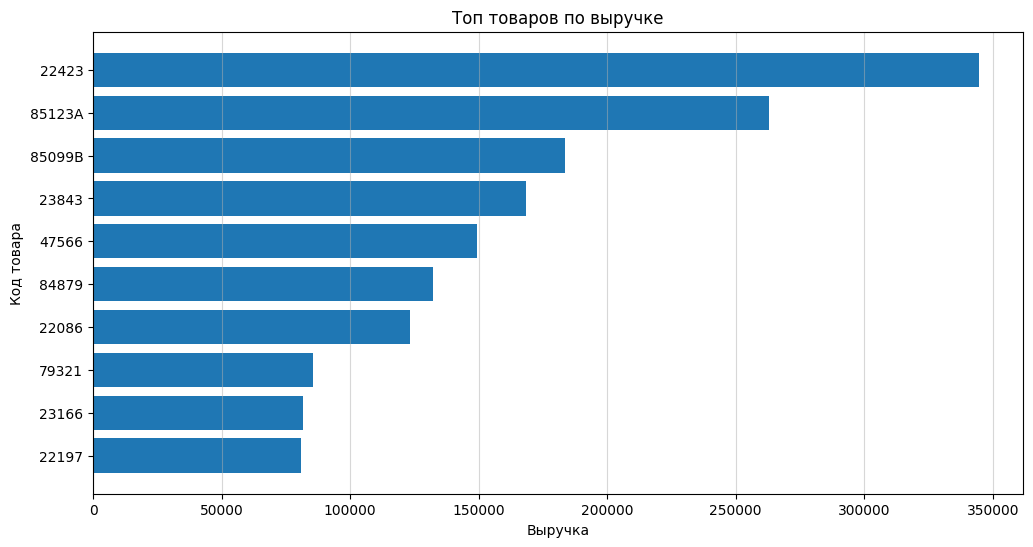

In [275]:
top_products = products.head(10).sort_values('GrossRevenue')

plt.figure(figsize=(12, 6))
plt.barh(top_products['StockCode'], top_products['GrossRevenue'])
plt.xlabel('Выручка')
plt.ylabel('Код товара')
plt.title('Топ товаров по выручке')
plt.grid(axis='x', alpha=0.5)

## 8. Клиенты и RFM-сегментация

RFM показывает:

- Recency - как давно клиент покупал
- Frequency - сколько заказов сделал
- Monetary - сколько денег принес

Чем выше итоговый сегмент, тем ценнее клиент для бизнеса.

In [276]:
customers = orders.dropna(subset=['CustomerID']).groupby('CustomerID').agg(
    FirstOrderDate=('InvoiceDate', 'min'),
    LastOrderDate=('InvoiceDate', 'max'),
    Orders=('Invoice', 'nunique'),
    GrossRevenue=('GrossRevenue', 'sum'),
    NetRevenue=('NetRevenue', 'sum'),
    Country=('Country', 'last')
).reset_index()

analysis_date = orders['InvoiceDate'].max()
customers['Recency'] = (analysis_date - customers['LastOrderDate']).dt.days
customers['Frequency'] = customers['Orders']
customers['Monetary'] = customers['GrossRevenue']

customers['RScore'] = pd.qcut(customers['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)
customers['FScore'] = pd.qcut(customers['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
customers['MScore'] = pd.qcut(customers['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)

customers['RFMTotal'] = customers['RScore'] + customers['FScore'] + customers['MScore']

def get_segment(row):
    if row['RScore'] >= 4 and row['FScore'] >= 4 and row['MScore'] >= 4:
        return 'Champion'
    if row['RScore'] >= 3 and row['FScore'] >= 4:
        return 'Loyal Customer'
    if row['RScore'] >= 4 and row['FScore'] <= 2:
        return 'New Customer'
    if row['RScore'] <= 2 and row['FScore'] >= 3:
        return 'At Risk'
    if row['RScore'] <= 2 and row['FScore'] <= 2:
        return 'Lost'
    return 'Regular Customer'

customers['Segment'] = customers.apply(get_segment, axis=1)

customers.head()

,CustomerID,FirstOrderDate,LastOrderDate,Orders,GrossRevenue,NetRevenue,Country,Recency,Frequency,Monetary,RScore,FScore,MScore,RFMTotal,Segment
0,12346.0,2010-03-02 13:08:00,2011-01-18 10:17:00,4,77352.96,169.36,United Kingdom,325,4,77352.96,2,3,5,10,At Risk
1,12347.0,2010-10-31 14:20:00,2011-12-07 15:52:00,8,5633.32,5633.32,Iceland,1,8,5633.32,5,4,5,14,Champion
2,12348.0,2010-09-27 14:59:00,2011-09-25 13:13:00,5,1658.40,1658.40,Finland,74,5,1658.40,3,3,4,10,Regular Customer
3,12349.0,2009-12-04 12:49:00,2011-11-21 09:51:00,4,3678.69,3654.54,Italy,18,4,3678.69,4,3,5,12,Regular Customer
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,294.40,294.40,Norway,309,1,294.40,2,1,2,5,Lost


In [277]:
customers.to_csv('../data/aggregates/customer_rfm.csv', index=False)

In [278]:
rfm_summary = customers.groupby('Segment').agg(
    Customers=('CustomerID', 'nunique'),
    GrossRevenue=('GrossRevenue', 'sum'),
    Orders=('Orders', 'sum')
).reset_index().sort_values('GrossRevenue', ascending=False)

rfm_summary

,Segment,Customers,GrossRevenue,Orders
1,Champion,1292,11922961.33,26569
3,Loyal Customer,680,1863354.85,6269
0,At Risk,844,1641429.32,5145
5,Regular Customer,1097,1168981.91,3157
2,Lost,1506,593241.62,2016
4,New Customer,456,244480.95,720


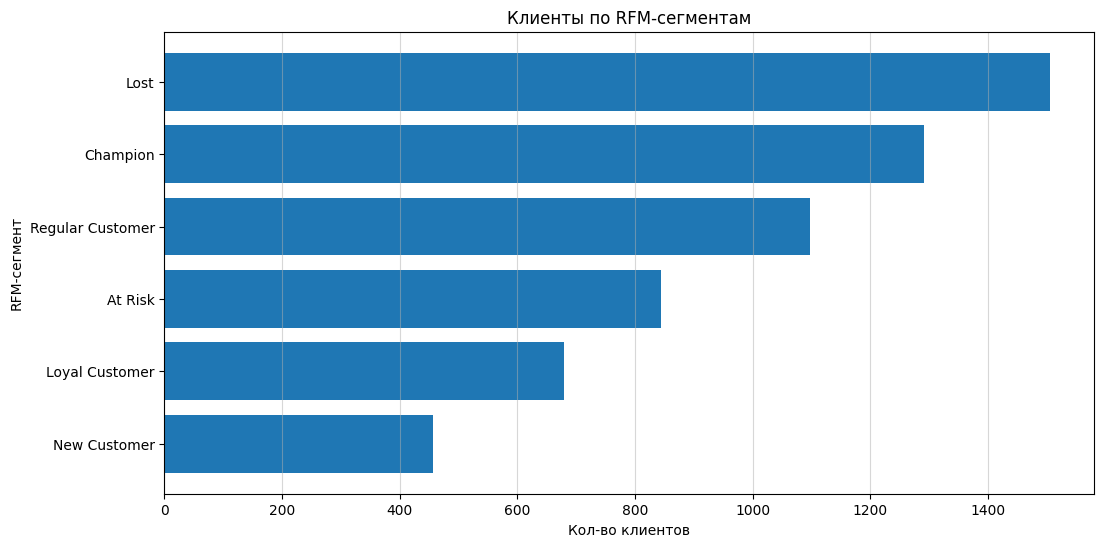

In [279]:
plt.figure(figsize=(12, 6))
plt.barh(rfm_summary.sort_values('Customers')['Segment'], rfm_summary.sort_values('Customers')['Customers'])
plt.xlabel('Кол-во клиентов')
plt.ylabel('RFM-сегмент')
plt.title('Клиенты по RFM-сегментам')
plt.grid(axis='x', alpha=0.5)

## 9. Когортный retention

In [280]:
cohort_data = sales_orders.dropna(subset=['CustomerID']).copy()
cohort_data['OrderMonth'] = cohort_data['InvoiceDate'].dt.to_period('M')

first_month = cohort_data.groupby('CustomerID')['OrderMonth'].min()
cohort_data['CohortMonth'] = cohort_data['CustomerID'].map(first_month)

cohort = cohort_data.groupby(['CohortMonth', 'OrderMonth'])['CustomerID'].nunique().reset_index()
cohort = cohort.rename(columns={'CustomerID': 'ActiveCustomers'})

cohort['CohortIndex'] = [
    (pd.Period(order_month, freq='M') - pd.Period(cohort_month, freq='M')).n
    for cohort_month, order_month in zip(cohort['CohortMonth'], cohort['OrderMonth'])
]

cohort_size = cohort[cohort['CohortIndex'] == 0][['CohortMonth', 'ActiveCustomers']]
cohort_size = cohort_size.rename(columns={'ActiveCustomers': 'CohortSize'})

cohort = cohort.merge(cohort_size, on='CohortMonth', how='left')
cohort['Retention'] = cohort['ActiveCustomers'] / cohort['CohortSize']

cohort.head()

,CohortMonth,OrderMonth,ActiveCustomers,CohortIndex,CohortSize,Retention
0,2009-12,2009-12,951,0,951,1.000000
1,2009-12,2010-01,333,1,951,0.350158
2,2009-12,2010-02,317,2,951,0.333333
3,2009-12,2010-03,404,3,951,0.424816
4,2009-12,2010-04,360,4,951,0.378549


In [281]:
cohort.to_csv('../data/aggregates/cohort_retention.csv', index=False)

In [282]:
retention_pivot = cohort.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='Retention'
)

retention_pivot.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.350158,0.333333,0.424816,0.378549,0.359621,0.376446,0.343849,0.337539,0.361725,0.421661,0.496320,0.376446,0.281809,0.243954,0.302839,0.262881,0.302839,0.283912,0.258675,0.254469,0.313354,0.303891,0.405889,0.196635
2010-01,1.0,0.214674,0.320652,0.315217,0.271739,0.309783,0.269022,0.233696,0.285326,0.326087,0.309783,0.179348,0.228261,0.179348,0.195652,0.152174,0.244565,0.203804,0.192935,0.201087,0.252717,0.198370,0.252717,0.057065,NaN
2010-02,1.0,0.234667,0.226667,0.293333,0.245333,0.197333,0.192000,0.288000,0.256000,0.277333,0.114667,0.125333,0.152000,0.176000,0.122667,0.200000,0.160000,0.162667,0.144000,0.229333,0.229333,0.165333,0.058667,NaN,NaN
2010-03,1.0,0.190476,0.231293,0.242630,0.231293,0.204082,0.247166,0.306122,0.276644,0.108844,0.115646,0.145125,0.199546,0.163265,0.199546,0.170068,0.174603,0.156463,0.176871,0.204082,0.213152,0.077098,NaN,NaN,NaN
2010-04,1.0,0.190476,0.190476,0.159864,0.183673,0.221088,0.275510,0.265306,0.105442,0.108844,0.074830,0.139456,0.142857,0.156463,0.156463,0.156463,0.139456,0.149660,0.180272,0.227891,0.057823,NaN,NaN,NaN,NaN


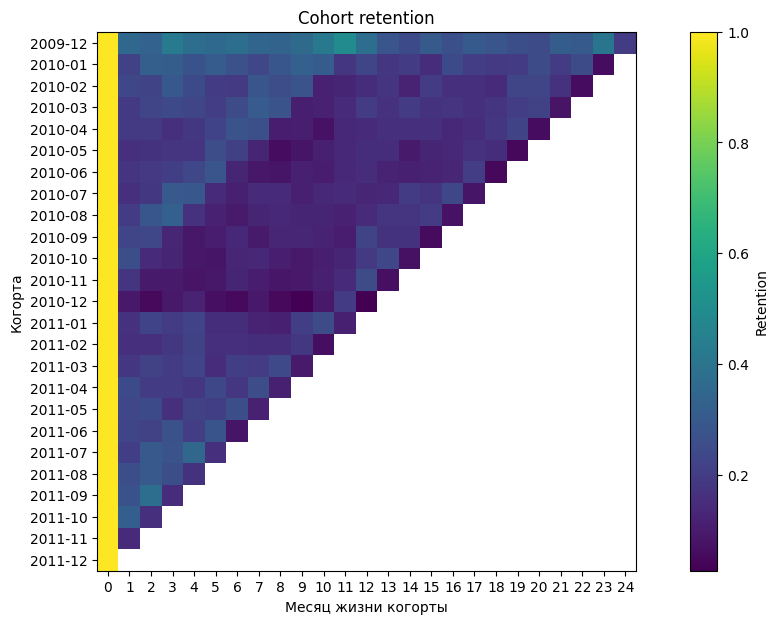

In [283]:
plt.figure(figsize=(14, 7))
plt.imshow(retention_pivot)
plt.xticks(range(len(retention_pivot.columns)), retention_pivot.columns)
plt.yticks(range(len(retention_pivot.index)), retention_pivot.index)
plt.xlabel('Месяц жизни когорты')
plt.ylabel('Когорта')
plt.title('Cohort retention')
plt.colorbar(label='Retention')

## 10. Финальные выводы

В этом ноутбуке получились основные таблицы для продуктовой аналитики:

- orders.csv — заказы
- main_metrics.csv — ключевые метрики
- monthly_kpi.csv — динамика по месяцам
- daily_kpi.csv — динамика по дням
- country_metrics.csv — страны
- product_metrics.csv — товары
- customer_rfm.csv — клиенты и RFM
- cohort_retention.csv — удержание по когортам